Dataset Loaded Successfully!

First 5 Rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Dataset Shape:
(20640, 10)

Da

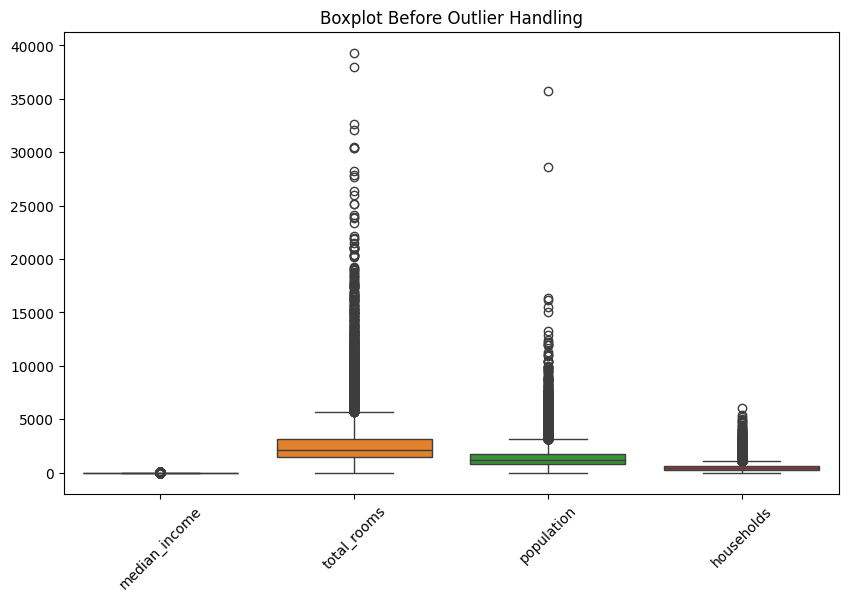


Outlier capping completed successfully!


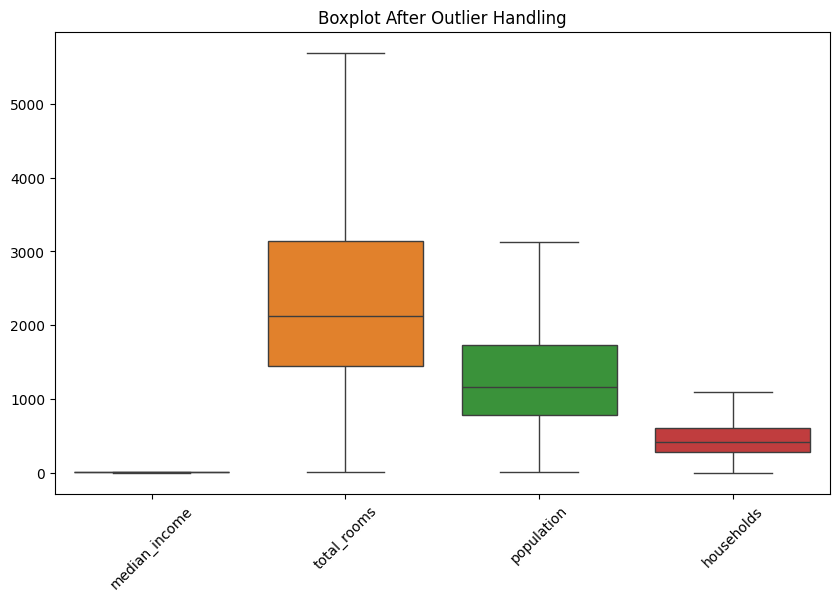


Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']

Target:
median_house_value

Numerical Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

Categorical Features:
['ocean_proximity']


MIN-MAX SCALING

Data After Min-Max Scaling:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   0.211155  0.567481            0.784314     0.154133        0.110190   
1   0.212151  0.565356            0.392157     1.000000        0.951254   
2   0.210159  0.564293            1.000000     0.257181        0.162703   
3   0.209163  0.564293            1.000000     0.223300        0.201442   
4   0.209163  0.564293            1.000000     0.285269        0.240181   

   population  households  median_income  median_house_value ocean_proximity  
0    0.101950    0.114521       1.000000         

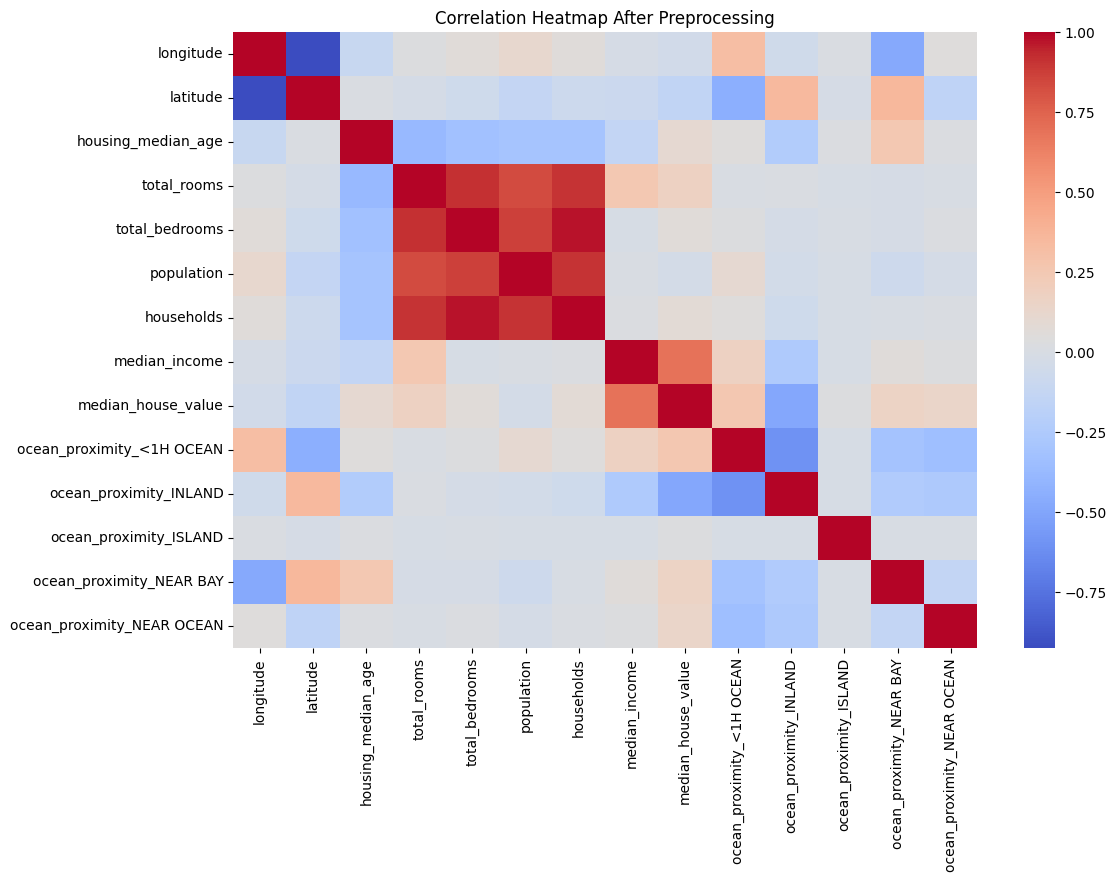


Training Data Shape:
(16512, 13)

Testing Data Shape:
(4128, 13)

Final Training Data:
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196    -117.03     32.71                33.0       3126.0           627.0   
8267     -118.16     33.77                49.0       3382.0           787.0   
17445    -120.48     34.66                 4.0       1897.0           331.0   
14265    -117.11     32.69                36.0       1421.0           367.0   
2271     -119.80     36.78                43.0       2382.0           431.0   

       population  households  median_income  ocean_proximity_<1H OCEAN  \
14196      2300.0       623.0         3.2596                          0   
8267       1314.0       756.0         3.8125                          0   
17445       915.0       336.0         4.1563                          0   
14265      1418.0       355.0         1.9425                          0   
2271        874.0       380.0         3.5542                  

In [3]:
# ============================================================
# EXPERIMENT 3
# California Housing Price Analysis and Prediction
# DATA PREPROCESSING
# ============================================================


# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    OneHotEncoder
)

from sklearn.model_selection import train_test_split


# ============================================================
# 2. LOAD THE DATASET
# ============================================================

# Change the filename if required

df = pd.read_csv("/content/housing prices.csv")

print("Dataset Loaded Successfully!")

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 3. CHECK DATASET SHAPE
# ============================================================

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# 4. CHECK DATASET INFORMATION
# ============================================================

print("\nDataset Information:")
df.info()


# ============================================================
# 5. CHECK DATA TYPES
# ============================================================

print("\nData Types:")
print(df.dtypes)


# ============================================================
# 6. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 7. MISSING VALUE PERCENTAGE
# ============================================================

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)


# ============================================================
# 8. HANDLE MISSING VALUES
# ============================================================

# Create a copy so that the original dataset remains unchanged

df_clean = df.copy()


# Find numerical columns

numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns


# Fill numerical missing values using median

for column in numeric_columns:

    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )


# Fill categorical missing values using mode

categorical_columns = df_clean.select_dtypes(
    include="object"
).columns


for column in categorical_columns:

    df_clean[column] = df_clean[column].fillna(
        df_clean[column].mode()[0]
    )


print("\nMissing Values After Handling:")

print(df_clean.isnull().sum())


# ============================================================
# 9. CHECK DUPLICATE ROWS
# ============================================================

print("\nNumber of Duplicate Rows:")

print(
    df_clean.duplicated().sum()
)


# ============================================================
# 10. REMOVE DUPLICATE ROWS
# ============================================================

df_clean = df_clean.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")

print(df_clean.shape)


# ============================================================
# 11. OUTLIER DETECTION USING IQR
# ============================================================

print("\n")
print("=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)


# Function to detect outliers using IQR

def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound


# Check outliers for selected columns

outlier_columns = [
    "median_house_value",
    "median_income",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households"
]


for column in outlier_columns:

    outliers, lower, upper = detect_outliers(
        df_clean,
        column
    )

    print(
        "\nColumn:",
        column
    )

    print(
        "Number of Outliers:",
        len(outliers)
    )

    print(
        "Lower Bound:",
        lower
    )

    print(
        "Upper Bound:",
        upper
    )


# ============================================================
# 12. BOXPLOT BEFORE OUTLIER HANDLING
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean[
        [
            "median_income",
            "total_rooms",
            "population",
            "households"
        ]
    ]
)

plt.title(
    "Boxplot Before Outlier Handling"
)

plt.xticks(rotation=45)

plt.show()


# ============================================================
# 13. HANDLE EXTREME OUTLIERS USING IQR
# ============================================================

# We will cap extreme values rather than deleting rows.
# This prevents unnecessary loss of data.


def cap_outliers(data, column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR

    upper_bound = Q3 + 1.5 * IQR

    data[column] = data[column].clip(
        lower_bound,
        upper_bound
    )

    return data


for column in outlier_columns:

    df_clean = cap_outliers(
        df_clean,
        column
    )


print(
    "\nOutlier capping completed successfully!"
)


# ============================================================
# 14. BOXPLOT AFTER OUTLIER HANDLING
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean[
        [
            "median_income",
            "total_rooms",
            "population",
            "households"
        ]
    ]
)

plt.title(
    "Boxplot After Outlier Handling"
)

plt.xticks(rotation=45)

plt.show()


# ============================================================
# 15. SEPARATE FEATURES AND TARGET
# ============================================================

X = df_clean.drop(
    "median_house_value",
    axis=1
)

y = df_clean[
    "median_house_value"
]


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("median_house_value")


# ============================================================
# 16. IDENTIFY NUMERICAL FEATURES
# ============================================================

numeric_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]


print("\nNumerical Features:")
print(numeric_features)


# ============================================================
# 17. IDENTIFY CATEGORICAL FEATURES
# ============================================================

categorical_features = [
    "ocean_proximity"
]


print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 18. MIN-MAX SCALING
# ============================================================

print("\n")
print("=" * 60)
print("MIN-MAX SCALING")
print("=" * 60)


minmax_scaler = MinMaxScaler()


df_minmax = df_clean.copy()


df_minmax[numeric_features] = (
    minmax_scaler.fit_transform(
        df_minmax[numeric_features]
    )
)


print(
    "\nData After Min-Max Scaling:"
)

print(
    df_minmax.head()
)


# ============================================================
# 19. STANDARD SCALING
# ============================================================

print("\n")
print("=" * 60)
print("STANDARD SCALING")
print("=" * 60)


standard_scaler = StandardScaler()


df_standard = df_clean.copy()


df_standard[numeric_features] = (
    standard_scaler.fit_transform(
        df_standard[numeric_features]
    )
)


print(
    "\nData After Standard Scaling:"
)

print(
    df_standard.head()
)


# ============================================================
# 20. ONE-HOT ENCODING
# ============================================================

print("\n")
print("=" * 60)
print("ONE-HOT ENCODING")
print("=" * 60)


df_encoded = pd.get_dummies(
    df_clean,
    columns=[
        "ocean_proximity"
    ],
    dtype=int
)


print(
    "\nDataset After One-Hot Encoding:"
)

print(
    df_encoded.head()
)


print(
    "\nNew Dataset Shape:"
)

print(
    df_encoded.shape
)


# ============================================================
# 21. DISPLAY ENCODED COLUMNS
# ============================================================

print("\nEncoded Columns:")

print(
    df_encoded.columns.tolist()
)


# ============================================================
# 22. CHECK DATASET AFTER PREPROCESSING
# ============================================================

print("\n")
print("=" * 60)
print("FINAL PREPROCESSED DATASET")
print("=" * 60)


print("\nShape:")
print(df_encoded.shape)


print("\nMissing Values:")
print(df_encoded.isnull().sum())


print("\nData Types:")
print(df_encoded.dtypes)


# ============================================================
# 23. CORRELATION AFTER PREPROCESSING
# ============================================================

correlation = df_encoded.corr(
    numeric_only=True
)


print("\nCorrelation with Median House Value:")

print(
    correlation[
        "median_house_value"
    ].sort_values(
        ascending=False
    )
)


# ============================================================
# 24. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap After Preprocessing"
)

plt.show()


# ============================================================
# 25. TRAIN TEST SPLIT
# ============================================================

X = df_encoded.drop(
    "median_house_value",
    axis=1
)

y = df_encoded[
    "median_house_value"
]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\nTraining Data Shape:")
print(X_train.shape)


print("\nTesting Data Shape:")
print(X_test.shape)


# ============================================================
# 26. DISPLAY FINAL TRAINING DATA
# ============================================================

print("\nFinal Training Data:")

print(
    X_train.head()
)


# ============================================================
# 27. SAVE CLEANED DATASET
# ============================================================

df_encoded.to_csv(
    "cleaned_housing.csv",
    index=False
)


print(
    "\nCleaned dataset saved as:"
)

print(
    "cleaned_housing.csv"
)


# ============================================================
# 28. SAVE MIN-MAX SCALED DATASET
# ============================================================

df_minmax.to_csv(
    "housing_minmax_scaled.csv",
    index=False
)


print(
    "\nMin-Max scaled dataset saved as:"
)

print(
    "housing_minmax_scaled.csv"
)


# ============================================================
# 29. SAVE STANDARD SCALED DATASET
# ============================================================

df_standard.to_csv(
    "housing_standard_scaled.csv",
    index=False
)


print(
    "\nStandard scaled dataset saved as:"
)

print(
    "housing_standard_scaled.csv"
)


# ============================================================
# 30. EXPERIMENT 3 COMPLETED
# ============================================================

print("\n")
print("=" * 60)
print("EXPERIMENT 3 COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("""
Data preprocessing was successfully performed.

Steps completed:

1. Missing Value Handling
2. Duplicate Detection and Removal
3. Outlier Detection
4. Outlier Capping
5. Min-Max Scaling
6. Standard Scaling
7. One-Hot Encoding
8. Feature and Target Separation
9. Train-Test Split
10. Cleaned Dataset Generation
""")